# In silicoChIP on Kat's Atlas 5' eRNA

In [1]:
###################
## Load packages
###################
suppressPackageStartupMessages({
    library(scran)
    library(scater)
    library(Seurat)
    library(ArchR)
})
source('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code/revision/insilico_chip/utils.R')

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21



                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

In [2]:
###################
## I/O
###################
io = list()

io$indir = '/rds/project/rds-SDzz0CATGms/users/bt392/15_Kat_Atlas/results/'

#ATAC
io$ATAC_counts = file.path(io$indir, 'data/CITE_eRNA_counts.mtx')
io$ATAC_peaks = file.path(io$indir, 'data/CITE_eRNA_peaks.csv')

#RNA
io$RNA_counts = file.path(io$indir, 'data/CITE_RNA_counts.mtx')
io$RNA_genes = file.path(io$indir, 'data/CITE_RNA_genes.csv')

#Meta
io$meta = file.path(io$indir, 'data/CITE_metadata.csv')

#UMAP
io$umap = file.path(io$indir, 'data/CITE_UMAP.csv')

# output
io$outdir = file.path(io$indir, 'silico_chip/')
dir.create(io$outdir, recursive=TRUE, showWarnings =FALSE)

In [3]:
meta = fread(io$meta)

In [34]:
RNA_counts = Matrix::readMM(io$RNA_counts)
ATAC_counts = Matrix::readMM(io$ATAC_counts)

In [35]:
dim(RNA_counts)
dim(ATAC_counts)

[1] 195483  18634

[1] 195483 115715

In [36]:
RNA_genes = fread(io$RNA_genes)
ATAC_peaks = fread(io$ATAC_peaks)

In [37]:
nrow(meta)

[1] 195483

In [38]:
head(meta)

V1,rna:samplename,rna:sampleid,rna:runid,rna:condition,rna:sampleinfo,rna:expectedcells,rna:rna,rna:citeseq,rna:batch,⋯,annotation40,phase,coarse,leiden_fine,ext_annot,ext_annot1,num_annot,ext_annot2,n_counts,annot1
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,⋯,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<chr>
AAACCTGCATCACAAC-LK_pool_1,LK_pool_1,RBG40279,SLX21493,LK,1 x 12 week Male (CB57/bl6) + 1 x 12 week Female (CB56/bl6),20000,SIGAE9,SINAE3,0,⋯,Baso_Prog,S,6,"HSC-Immature-Ly_prog-MK_prog-Ery_1-Ery_2-Baso_Prog-Mo_prog-Neut_prog_1,8",My_Prog1,GMP,10,GMP,2105,GMP
AAACCTGCATGCCTTC-LK_pool_1,LK_pool_1,RBG40279,SLX21493,LK,1 x 12 week Male (CB57/bl6) + 1 x 12 week Female (CB56/bl6),20000,SIGAE9,SINAE3,0,⋯,Baso_Prog,S,6,"HSC-Immature-Ly_prog-MK_prog-Ery_1-Ery_2-Baso_Prog-Mo_prog-Neut_prog_1,8",My_Prog1,GMP,10,GMP,2066,GMP
AAACCTGGTCATTAGC-LK_pool_1,LK_pool_1,RBG40279,SLX21493,LK,1 x 12 week Male (CB57/bl6) + 1 x 12 week Female (CB56/bl6),20000,SIGAE9,SINAE3,0,⋯,Baso_Prog,S,6,"HSC-Immature-Ly_prog-MK_prog-Ery_1-Ery_2-Baso_Prog-Mo_prog-Neut_prog_1,8",My_Prog1,GMP,10,GMP,2948,GMP
AAACCTGTCAACGCTA-LK_pool_1,LK_pool_1,RBG40279,SLX21493,LK,1 x 12 week Male (CB57/bl6) + 1 x 12 week Female (CB56/bl6),20000,SIGAE9,SINAE3,0,⋯,Mo_prog,S,6,"HSC-Immature-Ly_prog-MK_prog-Ery_1-Ery_2-Baso_Prog-Mo_prog-Neut_prog_1,0",Mono_Prog,MoP,24,MoP,2506,MoDCP
AAACCTGTCAGAGCTT-LK_pool_1,LK_pool_1,RBG40279,SLX21493,LK,1 x 12 week Male (CB57/bl6) + 1 x 12 week Female (CB56/bl6),20000,SIGAE9,SINAE3,0,⋯,Baso_Prog,G2M,13,"HSC-Immature-Ly_prog-MK_prog-Ery_1-Ery_2-Baso_Prog-Mo_prog-Neut_prog_1,17",Baso_Prog,BasoP,1,BasoP,2179,BasoP
AAACCTGTCCTGCTTG-LK_pool_1,LK_pool_1,RBG40279,SLX21493,LK,1 x 12 week Male (CB57/bl6) + 1 x 12 week Female (CB56/bl6),20000,SIGAE9,SINAE3,0,⋯,Neut_prog_1,S,6,"HSC-Immature-Ly_prog-MK_prog-Ery_1-Ery_2-Baso_Prog-Mo_prog-Neut_prog_1,1",My_Prog2,MyP,29,MyP,2305,NeutP


In [39]:
rownames(RNA_counts) = meta$V1
rownames(ATAC_counts) = meta$V1

In [40]:
colnames(RNA_counts) = RNA_genes$V1
colnames(ATAC_counts) = paste0(ATAC_peaks$chr, ':', ATAC_peaks$start, '-', ATAC_peaks$end)

In [41]:
RNA_sce = SingleCellExperiment(list(counts = t(RNA_counts)))
ATAC_sce = SingleCellExperiment(list(counts = t(ATAC_counts)))

In [42]:
saveRDS(RNA_sce, file.path(io$outdir, 'RNA_sce.rds'))
saveRDS(ATAC_sce, file.path(io$outdir, 'ATAC_sce.rds'))

In [ ]:
RNA_sce
ATAC_sce

In [15]:
length(unique(meta$annot1))

[1] 49

In [16]:
BPPARAM$workers = 8

In [17]:
# Pseudobulk by clusters
rna.pb = aggregateAcrossCells(RNA_sce, id=as.factor(meta$annot1), BPPARAM = BPPARAM)
atac.pb = aggregateAcrossCells(ATAC_sce, id=as.factor(meta$annot1), BPPARAM = BPPARAM)

In [18]:
rna.pb

class: SingleCellExperiment 
dim: 18634 49 
metadata(0):
assays(1): counts
rownames(18634): Mrpl15 Lypla1 ... CAAA01147332.1 AC149090.1
rowData names(0):
colnames(49): Baso BasoP ... T reg Transitional B
colData names(2): ids ncells
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [20]:
# normalize peak values for peak length (counts per kb)
counts(atac.pb) = counts(atac.pb) / ATAC_peaks[, peak_size]

In [21]:
assay(rna.pb,"logcounts") <- log(1e6*(sweep(assay(rna.pb),2,colSums(assay(rna.pb),na.rm=T),"/"))+1) 
assay(atac.pb,"logcounts") <- log(1e6*(sweep(assay(atac.pb),2,colSums(assay(atac.pb),na.rm=T),"/"))+1)

### Cisbp

In [24]:
peakSet = makeGRangesFromDataFrame(ATAC_peaks[, .(chr, start, end)])
head(peakSet)

GRanges object with 6 ranges and 0 metadata columns:
      seqnames          ranges strand
         <Rle>       <IRanges>  <Rle>
  [1]     chr1 4699342-4699722      *
  [2]     chr1 4705129-4705433      *
  [3]     chr1 4714121-4714574      *
  [4]     chr1 4729397-4729734      *
  [5]     chr1 4731628-4731950      *
  [6]     chr1 4732850-4733189      *
  -------
  seqinfo: 21 sequences from an unspecified genome; no seqlengths

In [25]:
## Get motif matches for example motifs in peaks 
## Adapted from: https://rdrr.io/github/GreenleafLab/ArchR/src/R/AnnotationPeaks.R
# Load motifs
library(motifmatchr)
library(chromVARmotifs)
library(chromVAR)

data("mouse_pwms_v2")
motifs <- mouse_pwms_v2
obj <- ArchR:::.summarizeChromVARMotifs(motifs)
motifs <- obj$motifs
motifSummary <- obj$motifSummary
names(motifs) = gsub( 'Tcfap', 'tfap', names(motifs))

# Find scores
motifmatcher.se <-  motifmatchr::matchMotifs(pwms = motifs, 
                                        subject = peakSet, 
                                        genome = "mm10", 
                                        out = 'scores',
                                        p.cutoff = 5e-05,
                                        w = 7) 




Attaching package: ‘XVector’


The following object is masked from ‘package:purrr’:

    compact


The following object is masked from ‘package:plyr’:

    compact



Attaching package: ‘Biostrings’


The following object is masked from ‘package:grid’:

    pattern


The following object is masked from ‘package:base’:

    strsplit




In [26]:
grep('Fli', colnames(motifmatcher.se))

[1] 277

In [28]:
motifmatcher.se

class: RangedSummarizedExperiment 
dim: 115715 884 
metadata(0):
assays(3): motifScores motifMatches motifCounts
rownames: NULL
rowData names(0):
colnames(884): tfap2a_1 tfap2b_2 ... Smad5_883 Smad9_884
colData names(1): name

In [30]:
# Add peak names to objects
rownames(motifmatcher.se) = rownames(atac.pb)

motif2gene.dt = data.table(motif = colnames(motifmatcher.se),
                           gene = toupper(str_split(colnames(motifmatcher.se), '_') %>% map_chr(1)))

In [31]:
###################
## Correlate TF-expr & Region-accessibility
###################  
a = Sys.time()
tf2peak_cor.se = cor_TF_acc(rna.sce = rna.pb, 
                          atac.sce = atac.pb, 
                          TFs_filt = NULL, #colData(motifmatcher.se)$name,  # c('SOX17', 'MYBL1') -> test runs
                          motifmatcher.se = motifmatcher.se, 
                          motif2gene.dt = motif2gene.dt,
                          correlation_method = "pearson", 
                          remove_motifs = NULL,
                          cores=24) # got an error this time with more cores
b = Sys.time()
b-a
# Make sure no multicore errors!!!

[1] "Removing 3 TFs that have duplicated gene-motif pairs:\nGM5294, NFIL3, ZFP263"


Correlate TF-expr & Region-accessibility for 471 TFs



Time difference of 17.28813 secs

In [32]:
######################################
## Create virtual chip-seq library 
######################################
a = Sys.time()
motifmatcher_chip.se = silico_chip(atac.sce = atac.pb, 
                           tf2peak_cor.se = tf2peak_cor.se,
                           motifmatcher.se = motifmatcher.se,
                           motif2gene.dt = motif2gene.dt, 
                           min_number_peaks = 50,
                           TFs_filt = NULL, 
                           remove_motifs = NULL,
                           cores = 24)
b = Sys.time()
b-a

[1] "Number of peaks: 115715"
[1] "Predicting TF binding sites..."
[1] "Number of TFs: 471"
[1] "Updating motifmatchr results using the virtual ChIP-seq library..."


Time difference of 10.75399 secs

In [33]:
saveRDS(motifmatcher_chip.se$motifmatcher_chip.se, file.path(io$outdir, 'eRNA_silicoChIP_cisbp.rds'))

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


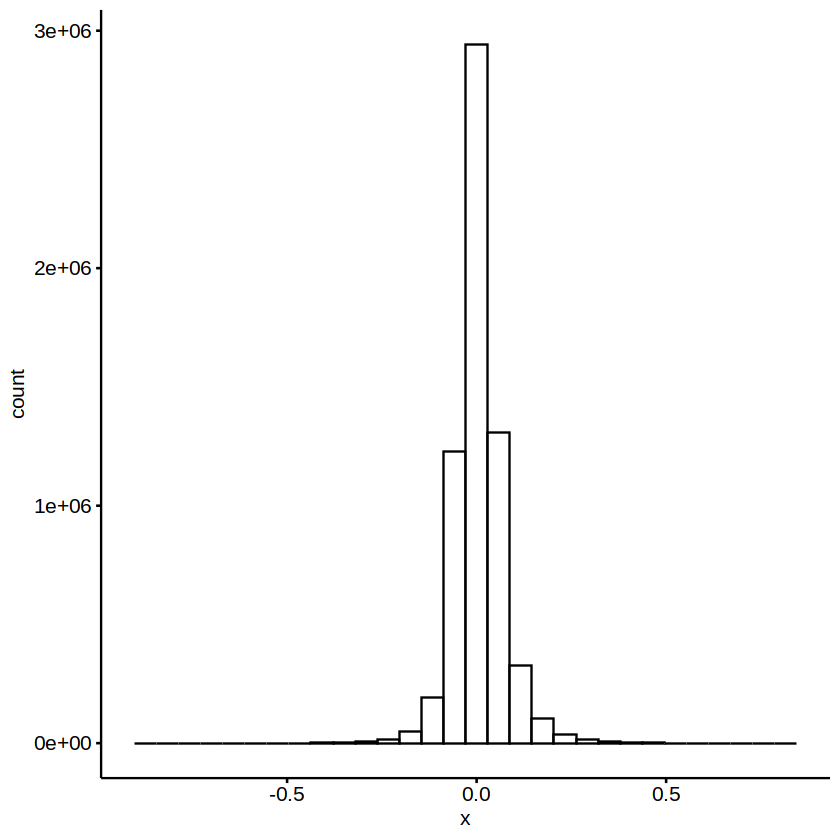

In [34]:
gghistogram(motifmatcher_chip.se$virtual_chip.dt$score)

In [5]:
motifmatcher_chip.se = readRDS(file.path(io$outdir, 'eRNA_silicoChIP_cisbp.rds'))

In [6]:
motifmatcher_chip.se

class: RangedSummarizedExperiment 
dim: 115715 471 
metadata(0):
assays(4): motifScores motifMatches motifCounts VirtualChipScores
rownames(115715): chr1:4699342-4699722 chr1:4705129-4705433 ...
  chrY:90819079-90820931 chrY:90822310-90823194
rowData names(0):
colnames(471): AHCTF1 AHR ... ZKSCAN5 ZSCAN20
colData names(1): name

In [ ]:
######################################
## ChromVAR - ChIP-seq
######################################
a = Sys.time()

# Currently reads for ATAC_sce can go extremely high. 
# Should they be kept at e.g. 4 reads per cell?
# But the point is sort of that eRNA is more quantitative than ATAC, so maybe should not do this?
chromvar_deviations.se = chromVAR_chip(atac.sce = ATAC_sce, 
                                                   motifmatcher_chip.se = motifmatcher_chip.se,
                                                   assay = 'VirtualChipScores',
                                                   background = NULL, #bgdPeaks.se,
                                                   genome = BSgenome.Mmusculus.UCSC.mm10, # Only needed if background = NULL
                                                   positive_only = TRUE, 
                                                   min_chip_score = 0.15,
                                                   min_number_peaks = 50,
                                                   TFs_filt = NULL,
                                                   test = FALSE,
                                                   method = 'ArchR', # Option 'ArchR' or 'ChromVAR'
                                                   cores = 4)
b = Sys.time()
b-a

[1] "Number of matches before filtering negative TF binding values: 6350934"
[1] "Number of matches after filtering negative TF binding values: 3550727"
[1] "Number of matches before filtering based on minimum ChIP-seq score: 3550727"
[1] "Number of matches after filtering based on minimum ChIP-seq score: 143164"
69 TFs removed because they don't have enough binding sites: ARNT2 ATOH8 CEBPA CREBZF CREM CTCFL CUX2 DDIT3 DLX1 DMRT2 DMRTA2 E2F2 E2F7 E2F8 ETV1 FOXE1 GCM2 GLIS1 GLIS3 GMEB2 GRHL1 HESX1 HEY1 HMBOX1 HMX2 HOXA1 HOXB7 HOXB8 HOXC6 HOXC9 LBX2 LHX2 MEIS2 MLX MLXIPL MTF1 MYBL1 MYOG MYPOP NAIF1 NFE2L3 NFIB NR1H3 NR2E3 NR6A1 OVOL2 PBX3 PKNOX1 PLAGL1 POU4F1 PRRXL1 RFX4 RORB RORC RXRG SHOX2 SIM2 SIX1 SOX15 SOX5 SOX8 SP7 TBX2 TFAP2A THRB YBX2 ZBTB7A ZFP128 ZFP143 
Calculating background peaks 
Running ChromVAR-ChIP-seq (ArchR implementation) 


2025-04-09 16:44:35 :  : Deviations for Annotation 20 of 402, 6.064 mins elapsed.

2025-04-09 16:50:42 :  : Deviations for Annotation 40 of 402, 12.183 mins elapsed.

2025-04-09 16:56:44 :  : Deviations for Annotation 60 of 402, 18.22 mins elapsed.

2025-04-09 17:02:57 :  : Deviations for Annotation 80 of 402, 24.423 mins elapsed.

2025-04-09 17:09:07 :  : Deviations for Annotation 100 of 402, 30.6 mins elapsed.

2025-04-09 17:15:16 :  : Deviations for Annotation 120 of 402, 36.752 mins elapsed.

2025-04-09 17:21:29 :  : Deviations for Annotation 140 of 402, 42.968 mins elapsed.

2025-04-09 17:27:45 :  : Deviations for Annotation 160 of 402, 49.23 mins elapsed.

2025-04-09 17:33:52 :  : Deviations for Annotation 180 of 402, 55.352 mins elapsed.

2025-04-09 17:40:34 :  : Deviations for Annotation 200 of 402, 62.054 mins elapsed.

2025-04-09 17:46:48 :  : Deviations for Annotation 220 of 402, 68.277 mins elapsed.

2025-04-09 17:53:23 :  : Deviations for Annotation 240 of 402, 74.866 mins

In [ ]:
saveRDS(chromvar_deviations.se, file.path(io$outdir, 'eRNA_silicoChIP_cisbp_chromVAR.rds'))

In [18]:
umap = fread(io$umap)[-1,] %>% 
    .[, cell := colnames(chromvar_deviations.se)] %>%
    setnames(c('V2', 'V3'), c('umap1', 'umap2')) %>% 
    .[, V1 := NULL]

In [4]:
chromvar_deviations.se = readRDS(file.path(io$outdir, 'eRNA_silicoChIP_cisbp_chromVAR.rds'))
RNA_sce = readRDS(file.path(io$outdir, 'RNA_sce.rds'))

In [5]:
RNA_sce = scuttle::logNormCounts(RNA_sce)

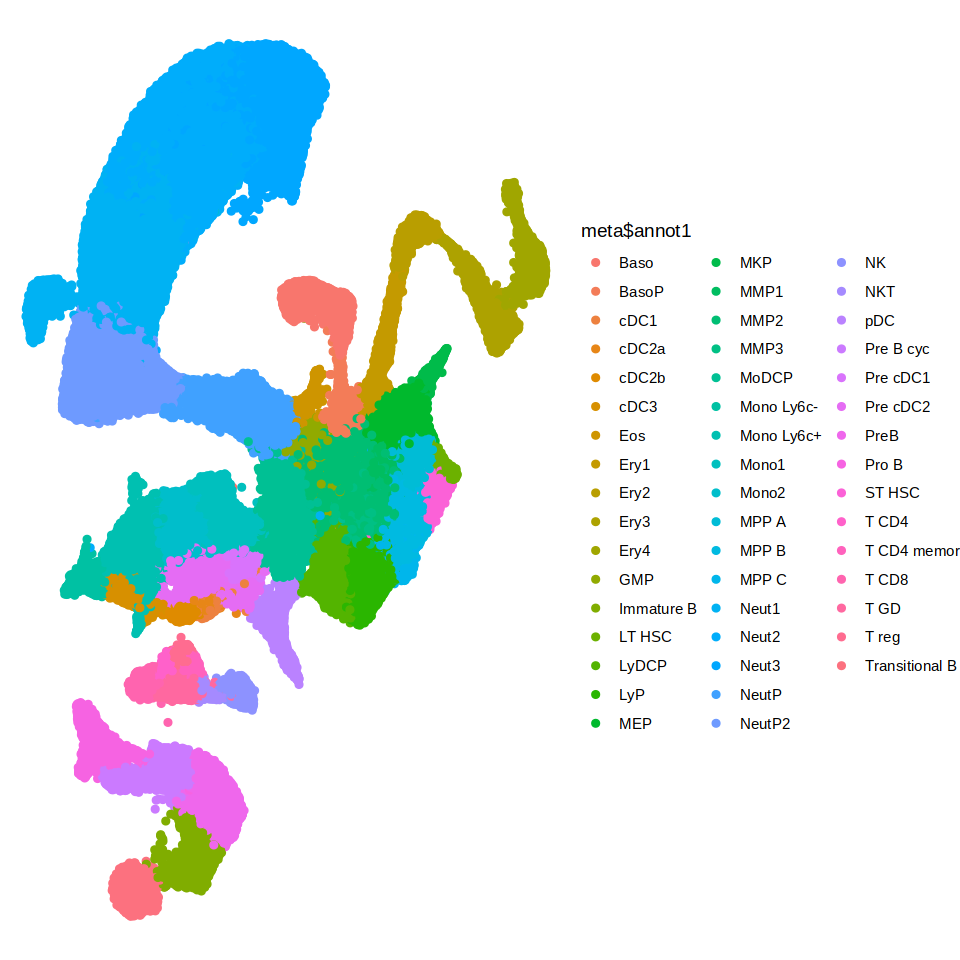

In [22]:
options(repr.plot.width = 8, repr.plot.height = 8)
ggplot(umap, aes(umap1, umap2)) + 
    geom_point(aes(color = meta$annot1)) + 
    theme_void()

In [8]:
RNA_sce

class: SingleCellExperiment 
dim: 18634 195483 
metadata(0):
assays(2): counts logcounts
rownames(18634): Mrpl15 Lypla1 ... CAAA01147332.1 AC149090.1
rowData names(0):
colnames(195483): AAACCTGCATCACAAC-LK_pool_1 AAACCTGCATGCCTTC-LK_pool_1
  ... TTTGTCATCCTCATTA-MNC_pool_4_5 TTTGTCATCTGGCGAC-MNC_pool_4_5
colData names(1): sizeFactor
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [11]:
TF = 'RUNX1'

In [12]:
head(as.numeric(logcounts(RNA_sce[str_to_title(TF),])))

In [ ]:
RNA_sce[str_to_title(TF),1:10]

In [19]:
plot_umap = function(TF){
    umap$TF = as.numeric(chromvar_deviations.se@assays@data$z[TF, umap$cell])
    umap$gene = as.numeric(logcounts(RNA_sce[str_to_title(TF),]))
    
    p1 = ggplot(umap[order(abs(TF))], aes(umap1, umap2, color = TF)) + 
        geom_point() + 
        scale_color_gradientn(colours = c('darkblue', 'white', 'darkred')) +
        ggtitle('in silico ChIP') +
        theme_void()
    p2 = ggplot(umap[order(abs(gene))], aes(umap1, umap2, color = gene)) + 
        geom_point() + 
        scale_color_gradientn(colours = c('darkblue', 'white', 'darkred')) +
        ggtitle('Gene Expression') +
        theme_void()
    
    ggarrange(p1, p2, align = 'hv', nrow = 1)
}

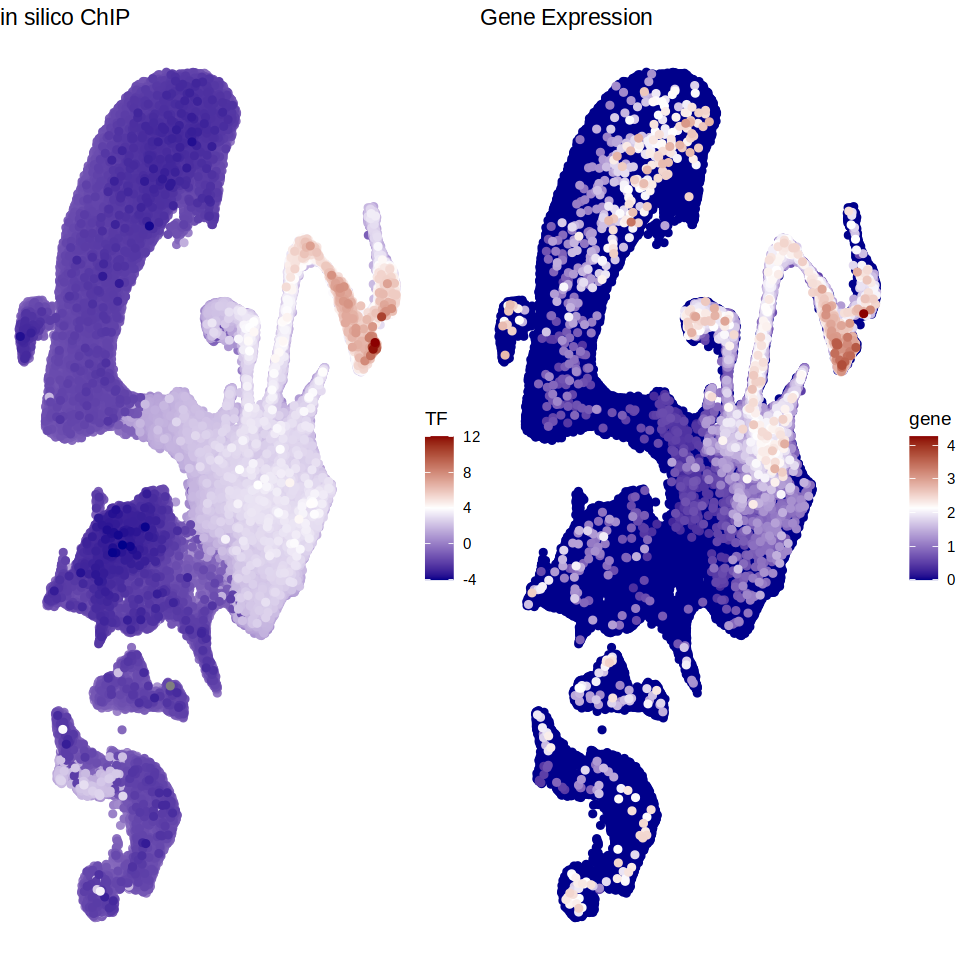

In [21]:
options(repr.plot.width = 15, repr.plot.height = 6)
plot_umap('GATA1')

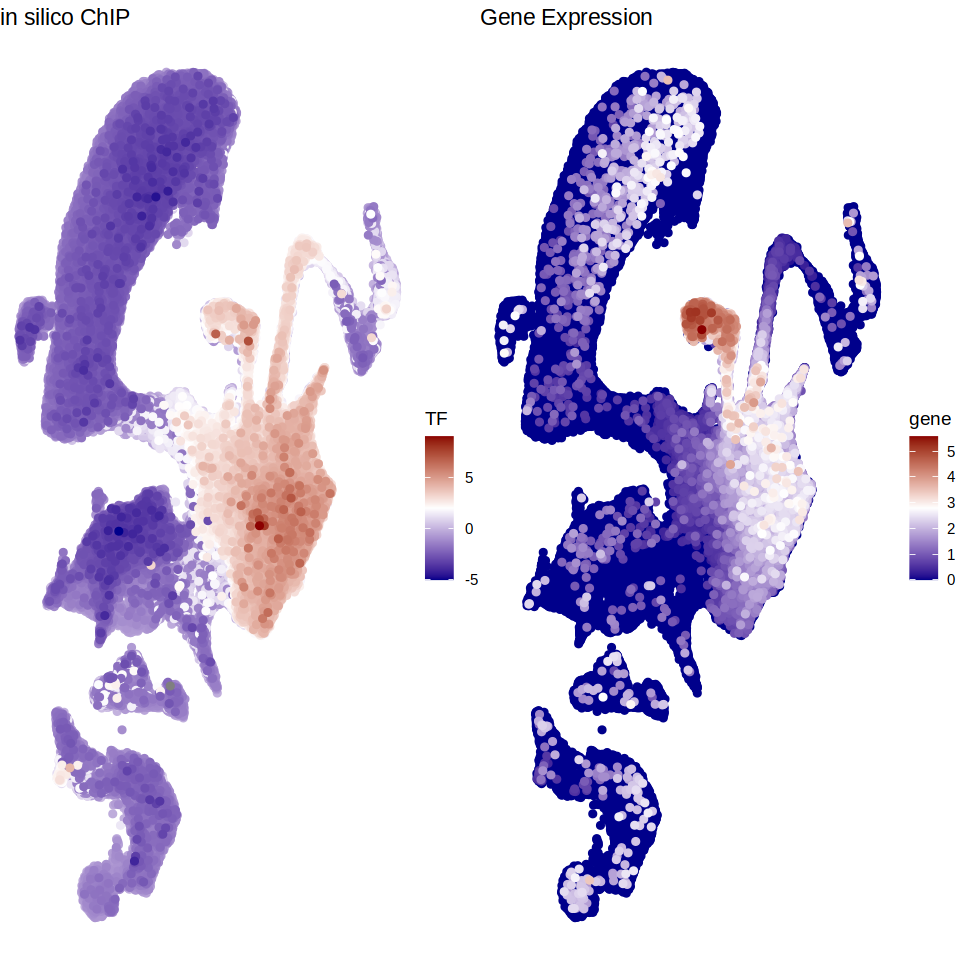

In [22]:
plot_umap('GATA2')

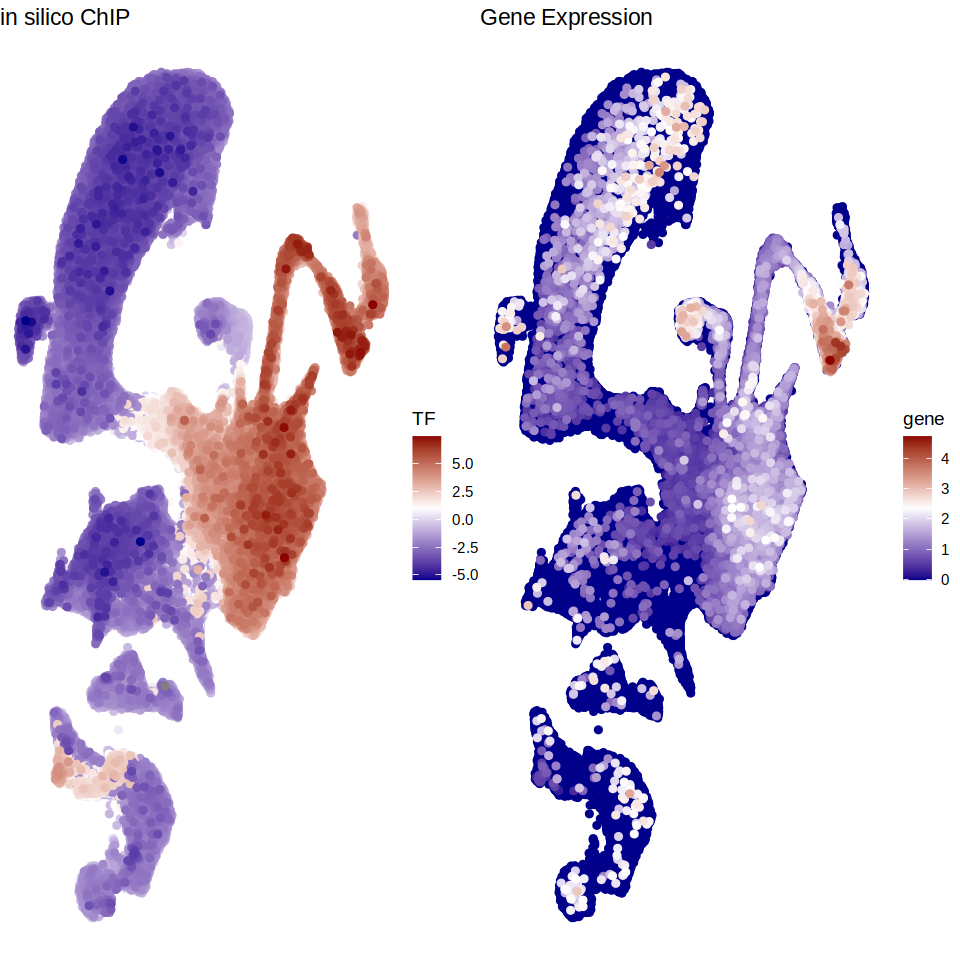

In [23]:
plot_umap('TAL1')

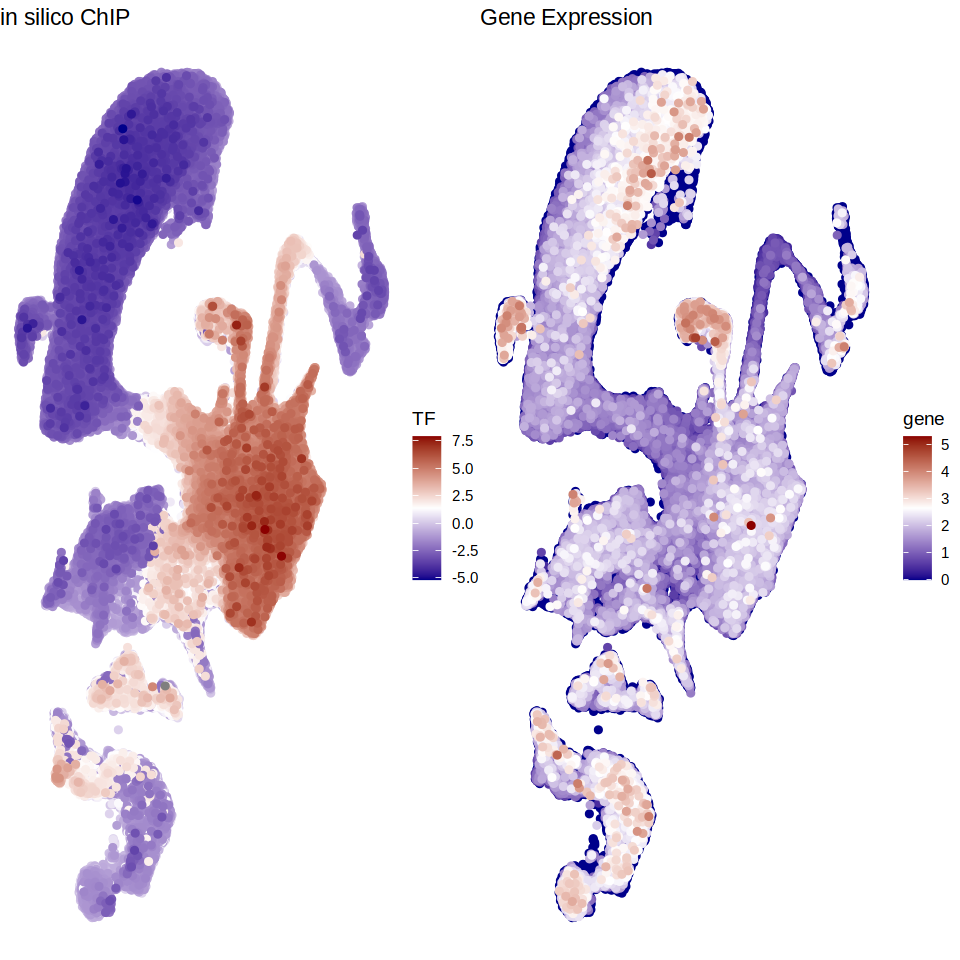

In [24]:
plot_umap('RUNX1')

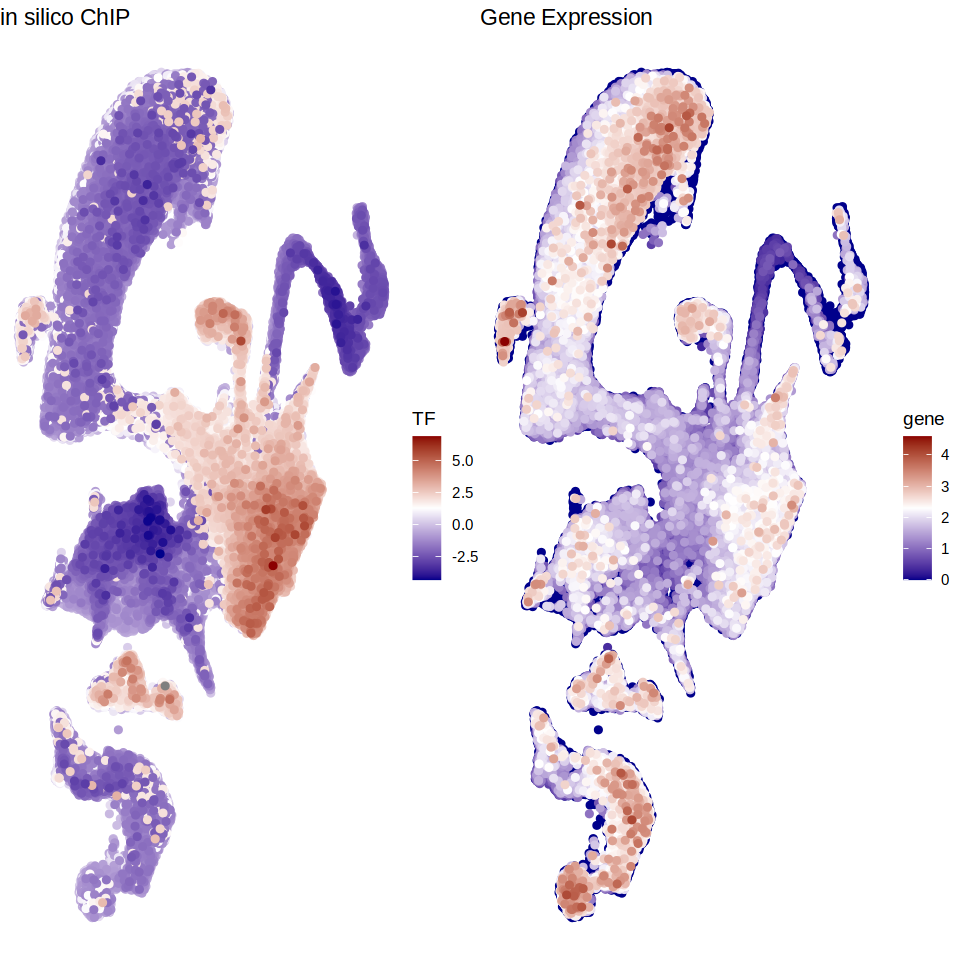

In [25]:
plot_umap('FLI1')